In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"

df = pd.read_csv(url)

df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (200, 5)


In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
print(df.isnull().sum())

TV           0
radio        0
newspaper    0
sales        0
dtype: int64


In [7]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


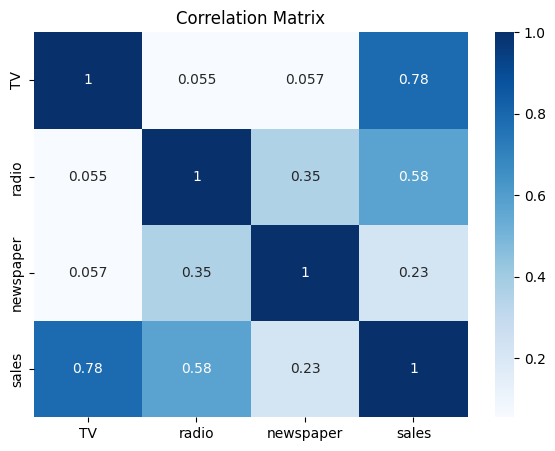

In [8]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

In [10]:
print(df.columns.tolist())

['TV', 'radio', 'newspaper', 'sales']


In [11]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


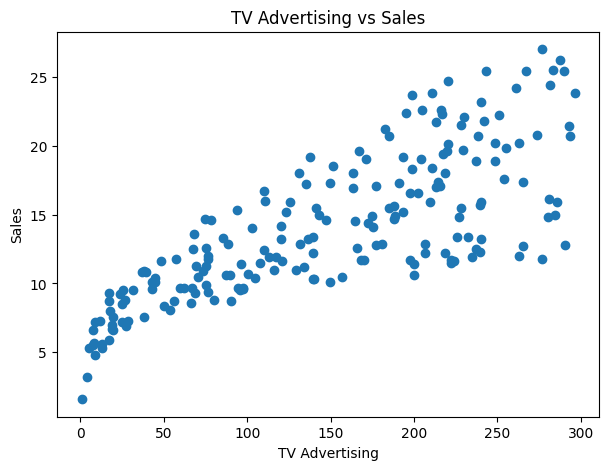

In [12]:
plt.figure(figsize=(7,5))

plt.scatter(df["TV"], df["sales"])

plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")

plt.show()

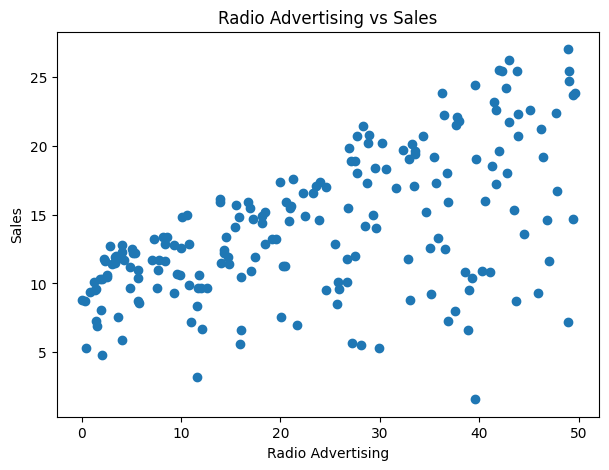

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(df["radio"], df["sales"])

plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.title("Radio Advertising vs Sales")

plt.show()

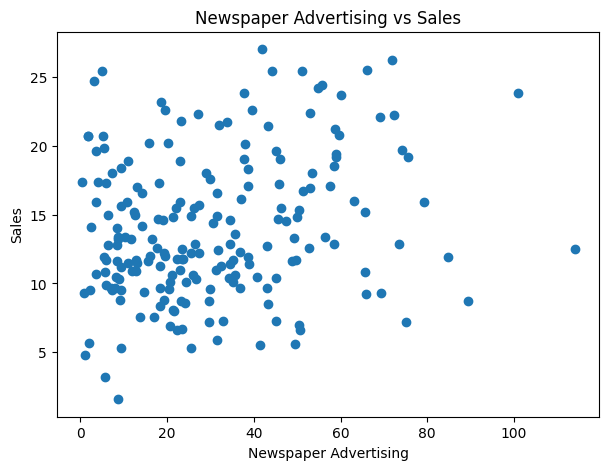

In [14]:
plt.figure(figsize=(7,5))

plt.scatter(df["newspaper"], df["sales"])

plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.title("Newspaper Advertising vs Sales")

plt.show()

In [15]:
X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  radio  newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [18]:
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred[:10])

Predicted Sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.4607567168117603
Mean Squared Error (MSE): 3.1740973539761033
Root Mean Squared Error (RMSE): 1.78159966153345
R² Score: 0.899438024100912


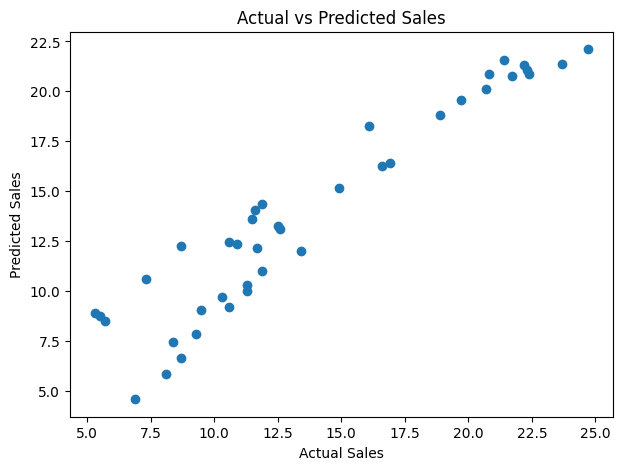

In [20]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## Conclusion

In this project, a Linear Regression model was developed to predict product sales based on advertising expenditure through TV, Radio, and Newspaper platforms.

The dataset was explored using descriptive statistics and visualizations. The data was divided into training and testing sets, and the Linear Regression model was trained using the training data.

The model was evaluated using MAE, MSE, RMSE, and R² score. The results demonstrate the relationship between advertising expenditure and product sales.